# **Aurora Siger - Pre-Takeoff Analysis**
### **RM:** 570266
### **Name:** Renato Nascimento
### **GitHub Repository:** https://github.com/RenatoBrevi/Phase-01-Aurora-Siger-Operational-Report

## 1.1 Organização e descrição da telemetria

Interpretar dados referentes a:

Temperatura interna e externa;
Integridade estrutural (0/1);
Níveis de energia (%);
Pressão dos tanques;
Status dos módulos críticos.

In [1]:
# Importing library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Reading csv file
df = pd.read_csv("telemetria_sintetica_500_linhas_abort.csv")

In [3]:
df.shape

(500, 16)

In [4]:
df.head(15)

,timestamp,internal_temp_c,external_temp_c,battery_voltage_v,battery_current_a,battery_soc_percent,battery_capacity_ah,energy_available_kwh,power_load_kw,energy_loss_percent,tank_pressure_bar,structural_integrity,critical_modules_status,telemetry_link_status,estimated_autonomy_min,launch_decision
0,2026-03-30T00:00:00,34.82,17.40,49.34,88.46,93.71,111.04,5.1341,9.58,2.19,110.77,1,1,1,81.15,READY
1,2026-03-30T00:01:00,21.59,28.00,51.26,51.47,86.22,95.83,4.2353,23.29,4.75,108.24,1,1,1,78.29,READY
2,2026-03-30T00:02:00,27.54,4.20,49.51,109.78,75.98,88.77,3.3393,24.95,5.06,99.55,1,1,1,51.36,READY
3,2026-03-30T00:03:00,19.86,16.96,50.75,62.22,62.54,95.26,3.0235,24.92,5.17,143.55,0,1,1,161.21,ABORT
4,2026-03-30T00:04:00,29.56,-0.99,51.31,95.09,90.74,93.61,4.3584,10.87,2.95,95.16,1,1,1,142.48,READY
5,2026-03-30T00:05:00,30.23,29.02,50.57,70.77,64.26,105.01,3.4124,21.83,5.05,104.95,1,1,1,95.48,READY
6,2026-03-30T00:06:00,20.75,28.37,51.53,111.85,83.96,99.54,4.3066,7.24,4.18,144.27,1,1,1,153.91,READY
7,2026-03-30T00:07:00,22.07,3.43,49.40,27.88,89.28,112.64,4.9679,24.56,5.20,101.29,1,1,1,134.07,READY
8,2026-03-30T00:08:00,34.10,0.78,49.17,80.66,98.57,117.16,5.6784,20.11,6.14,130.65,1,1,1,98.86,READY
9,2026-03-30T00:09:00,29.42,8.07,51.40,65.15,69.92,82.56,2.9671,5.42,5.32,124.42,1,1,1,45.97,READY


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    str    
 1   internal_temp_c          500 non-null    float64
 2   external_temp_c          500 non-null    float64
 3   battery_voltage_v        500 non-null    float64
 4   battery_current_a        500 non-null    float64
 5   battery_soc_percent      500 non-null    float64
 6   battery_capacity_ah      500 non-null    float64
 7   energy_available_kwh     500 non-null    float64
 8   power_load_kw            500 non-null    float64
 9   energy_loss_percent      500 non-null    float64
 10  tank_pressure_bar        500 non-null    float64
 11  structural_integrity     500 non-null    int64  
 12  critical_modules_status  500 non-null    int64  
 13  telemetry_link_status    500 non-null    int64  
 14  estimated_autonomy_min   500 non-null

In [6]:
# See what we got only in 'ABORT'
abortion = df[df["launch_decision"] == "ABORT"]
print(abortion)

               timestamp  internal_temp_c  external_temp_c  battery_voltage_v  \
3    2026-03-30T00:03:00            19.86            16.96              50.75   
12   2026-03-30T00:12:00            18.92            17.87              49.88   
13   2026-03-30T00:13:00            36.16             3.74              51.54   
15   2026-03-30T00:15:00            34.27            29.84              49.33   
16   2026-03-30T00:16:00            18.85            11.69              51.52   
..                   ...              ...              ...                ...   
483  2026-03-30T08:03:00            16.58             2.07              46.56   
486  2026-03-30T08:06:00            12.68             5.93              51.35   
490  2026-03-30T08:10:00            19.34            27.30              50.59   
494  2026-03-30T08:14:00            26.20            -2.69              47.25   
496  2026-03-30T08:16:00            19.85            23.49              50.63   

     battery_current_a  bat

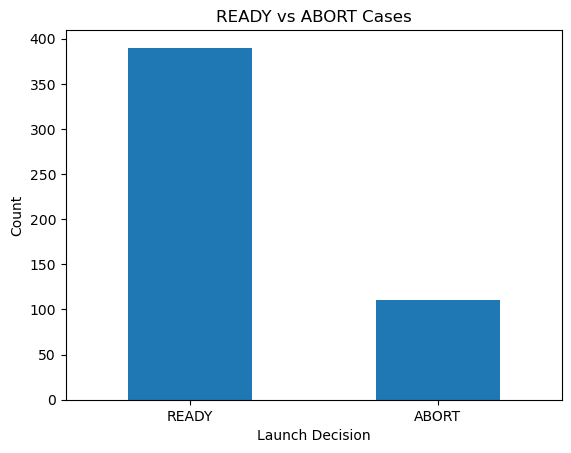

In [7]:
decision_counts = df["launch_decision"].value_counts()

decision_counts.plot(kind="bar")
plt.title("READY vs ABORT Cases")
plt.xlabel("Launch Decision")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

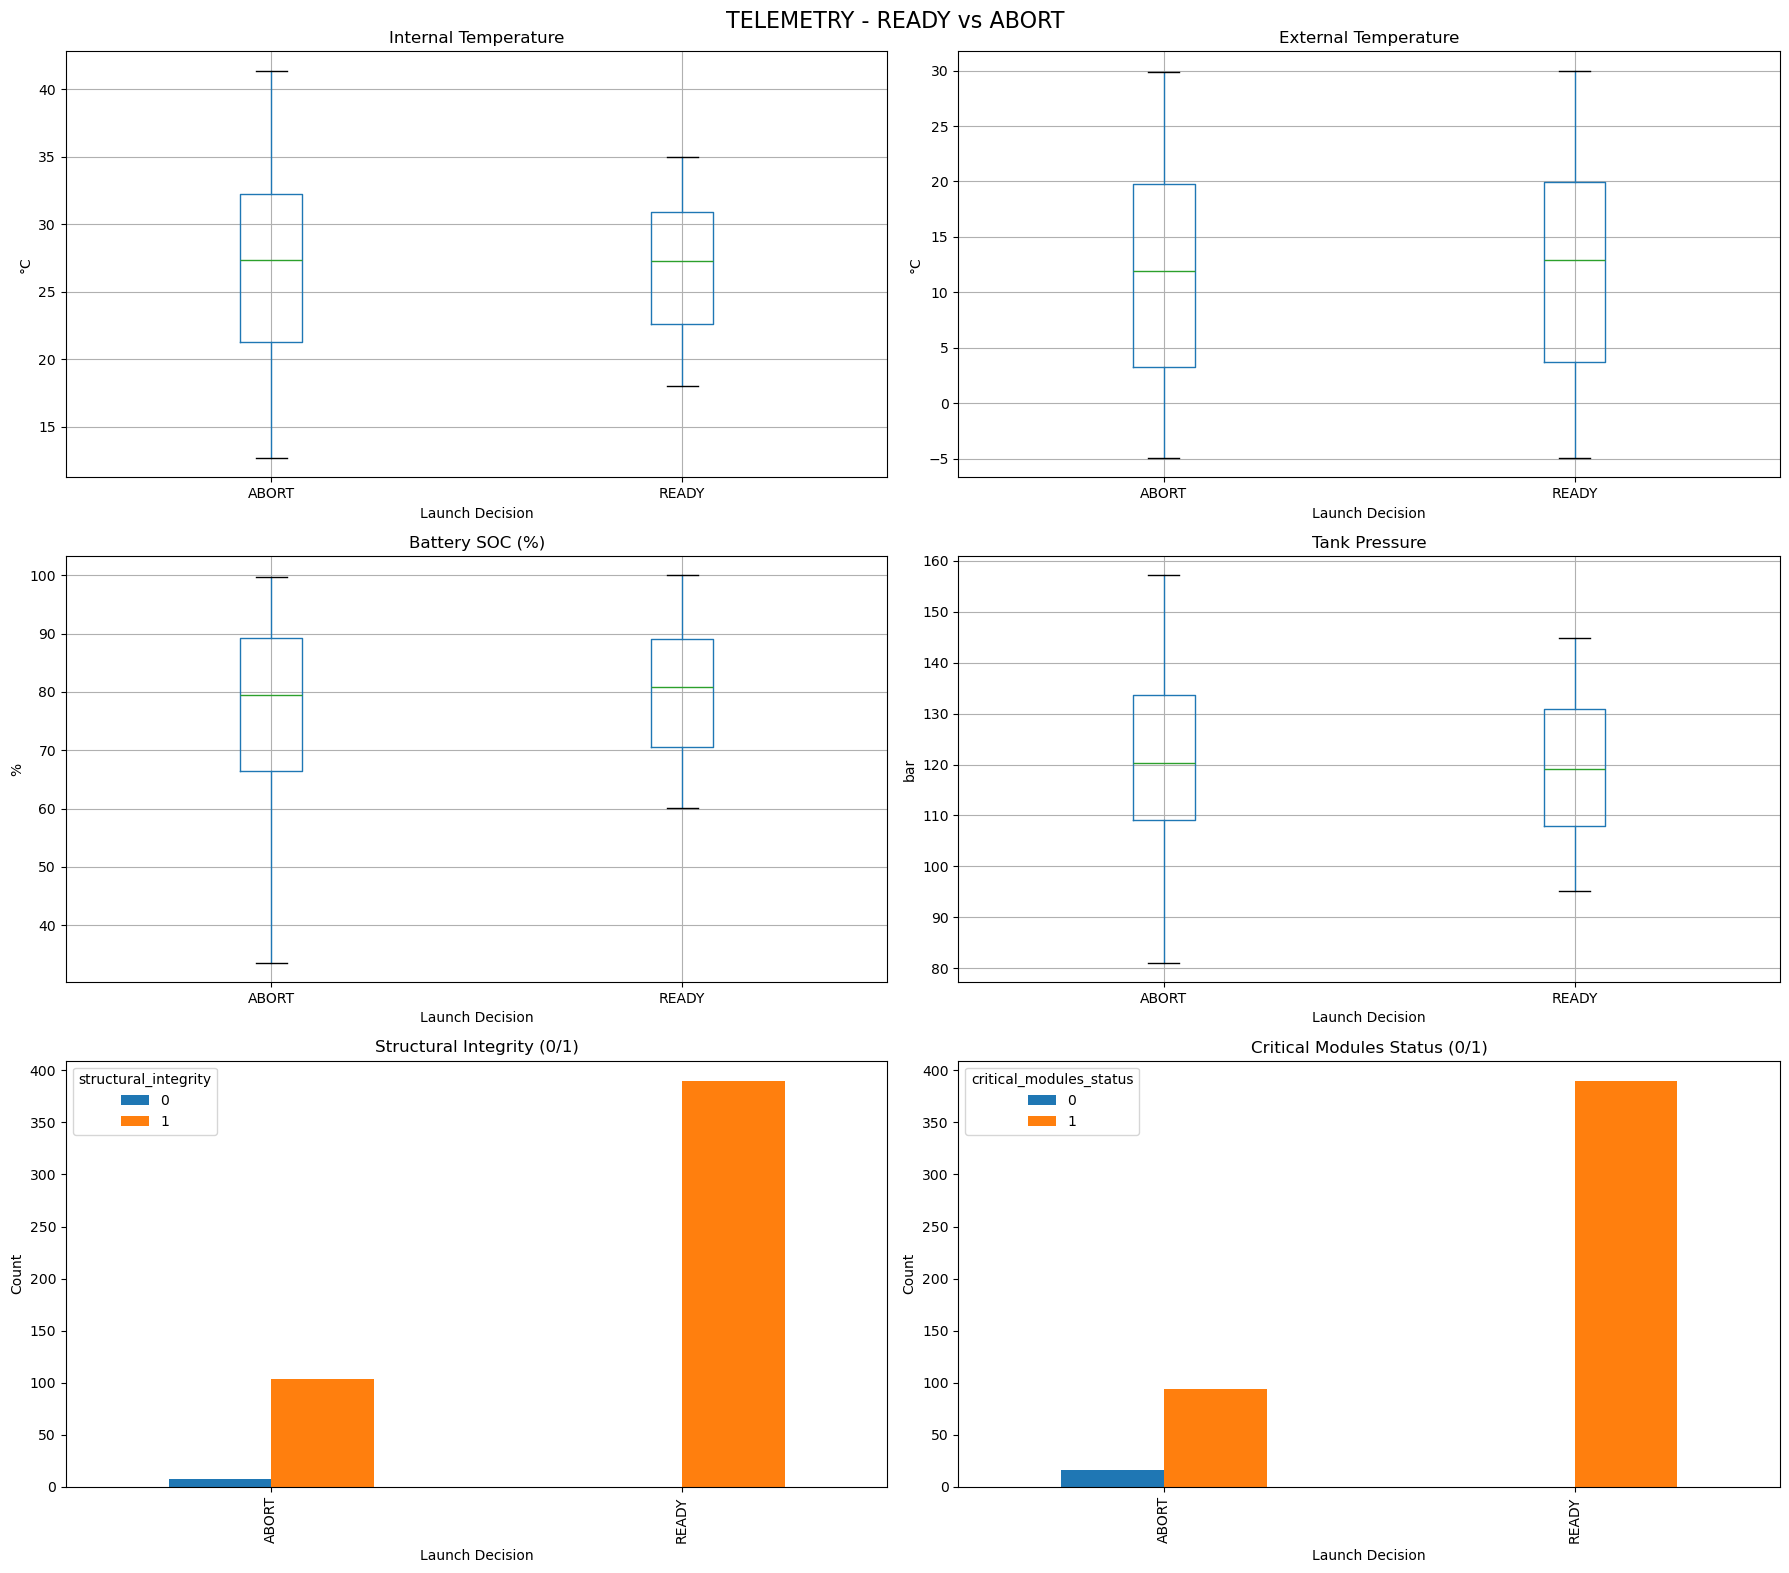

In [8]:
# Make the column is sBytesWarning
df["launch_decision"] = df["launch_decision"].astype(str)

# Creating a fugire with variable graphics
fig, axes = plt.subplots(3, 2, figsize=(18,16))
fig.suptitle("Telemetry: READY vs ABORT", fontsize=16)

# Internal Temperature
df.boxplot(column="internal_temp_c", by="launch_decision", ax=axes[0, 0]) # setting up as the frist graph
axes[0, 0].set_title("Internal Temperature")
axes[0, 0].set_xlabel("Launch Decision")
axes[0, 0].set_ylabel("°C")

# External Temperature
df.boxplot(column="external_temp_c", by="launch_decision", ax=axes[0, 1]) # setting up as the second graph
axes[0, 1].set_title("External Temperature")
axes[0, 1].set_xlabel("Launch Decision")
axes[0, 1].set_ylabel("°C")

# Energy Level from Battery (%)
df.boxplot(column="battery_soc_percent", by="launch_decision", ax=axes[1, 0]) # setting up as the third graph
axes[1, 0].set_title("Battery SOC (%)")
axes[1, 0].set_xlabel("Launch Decision")
axes[1, 0].set_ylabel("%")

# Tank Pressure 
df.boxplot(column="tank_pressure_bar", by="launch_decision", ax=axes[1, 1]) # setting up as the fourth graph
axes[1, 1].set_title("Tank Pressure")
axes[1, 1].set_xlabel("Launch Decision")
axes[1, 1].set_ylabel("bar")

# Sctruture Integrity
struct_counts = df.groupby(["launch_decision", "structural_integrity"]).size().unstack(fill_value=0)
struct_counts.plot(kind="bar", ax=axes[2,0]) #setting up as the fifth graph
axes[2, 0].set_title("Structural Integrity (0/1)")
axes[2, 0].set_xlabel("Launch Decision")
axes[2, 0].set_ylabel("Count")
axes[2, 0].legend(title="structural_integrity")

# Critical Module Status 
critical_counts = df.groupby(["launch_decision", "critical_modules_status"]).size().unstack(fill_value=0)
critical_counts.plot(kind="bar", ax=axes[2 , 1]) #setting up as the sixth graph
axes[2 , 1].set_title("Critical Modules Status (0/1)")
axes[2 , 1].set_xlabel("Launch Decision")
axes[2 , 1].set_ylabel("Count")
axes[2 , 1].legend(title="critical_modules_status")

# Removing pandas auto titles
plt.suptitle("TELEMETRY - READY vs ABORT", fontsize=16)
plt.tight_layout()
plt.show()

## **INTERPRETANTO OS DADOS**

### **[BR]** 

### Não foi splotado os outliers para termos uma visão mais geral

**Internal Temperature (Temperatura Interna)** - A temperatura interna tanto quando a nave está em modo "READY" como em modo "ABORT" tem uma distribuição parecida embora o "ABORT" tenha os bigodes muito maiores na parte de baixo do gráfico, o que mostra maior variação em relação ao "READY". As medianas estão bem próximas. Portanto a temperatura interna não se mostra como o agente causador para os casos de aborto, mesmo apresentado casos maiores de variação na parte de baixo. 

**External Temperature (Temperatura Externa)** = A temperatura externa apresenta medianas próximas e bigodes (whiskers) iguais, mostrando que tanto o "READY" como o "ABORT" têm bastante variações. A temperatura externa não está mostrando grande impacto entre "READY" e "ABORT".

**Structural Integrity (Integridade Estrutural)** - Todos os casos de "ABORT" se mostrando quando a integridade estrutural da nave estava em 0, já que é um fator decisivo para o mal funcionamento da nave. Ainda assim, uma quantidade significativa de abortos se deram enquanto a integridade estrutural da nave se encontrava em boas condições.

**Battery SOC (Níveis de Energia)** - Os níveis de energia estão com mediana similares entre os casos de "ABORT" e "READY". Quando os níveis de energia estão baixos as chances de ter aborto são grandes, mostrando muita variação com níveis baixos de bateria. Porém, ainda assim acontecem abortos com níveis de bateria altos.

**Tank Pressure (Pressão dos Tanques)** - Novamente o "ABORT" e "READY" estão com mediana similar, porém com variações grandes tanto com o tanque quase vazio, como com o tanque cheio.

**Critical Modules Status (Status dos Módulos Críticos)** - Como no "Structural Integrity" todos os casos onde o resultado foi 0 houve "ABORT" imediato, pois é uma variante essencial estar em bom funcionamento. Os casos abortados pelo resultado 0 foram superiores ao "Structural Integrity", o que aponta falhas maiores nos módulos críticos, necessitando de mais ateção. 

**Breve Conclusão** - Não existe neste caso um dado certeiro que faça com que sempre se obtenha o resultado "ABORT" com maior frequência em determinado tipo de operação, mas sim em cada parcela dos dados podendo resultar em "ABORT" se um único dado funcionar errado. Seguindo pela taxa de sucesso de quase 82% onde a nave não apresenta falhas para poder decolar, acredito que deve-se solucionar melhores abordagens para que essa taxa de "acerto" seja elevada para não correr o risco de explosão e perdas, já que vidas humanas estão em risco.

In [ ]:
ready = 500
abort = 110

total = ready + abort


ready_percent = (ready / total) * 100
abort_percent = (abort / total) * 100

print(f"READY: {ready_percent:.2f}%")
print(f"ABORT: {abort_percent:.2f}%")

## 1.2 Algoritmo de verificação

Construir um algoritmo (fluxograma/pseudocódigo) capaz de decidir: “PRONTO PARA DECOLAR” ou “DECOLAGEM ABORTADA” com base em faixas seguras predefinidas.

In [ ]:
# Fluxograma / pseudocodigo
"""
Inicío
    Funcao decisao_lancamento(linha)
        se linha.structural_integrity = 0 entao
            retorne "ABORT - Structural Failure"
        senao se linha.critical_modules_status = 0 entao
            retorne "ABORT - Critical Modules Failure" 
        senao se linha.telemetry_link_status = 0 entao
            retorne "ABORT - Telemetry Link Failure" 
        senao se linha.battery_soc_percent < 60 entao
            retorne "ABORT - Low Battery
        senao se linha.tank_pressure_bar < 95 ou linha.tank_pressure_bar > 145 entao
            retorne "ABORT - Unsafe Tank Pressure
        senao se linha.internal_temp_c < 18 ou linha.internal_temp_c > 35 entao
            retorne "ABORT - Unsafe Internal Temperature"%%!
        senao se linha.external_temp_c < -5 ou linha.external_temp_c > 30 entao
            retorne "ABORT - Unsafe External Temperature" 
        senao
            retorne "READY TO LAUNCH"
        FIM SE

    fim funcao

    para cada linha no dataframe faca
        linha.nova_decisao_lancamento = decisao_lancamento(linha)
    fim para

    exibir as 30 primeiras linhas com:
        timestamp,
        structural_integrity, 
        critical_modules_status, 
        telemetry_link_status, 
        battery_soc_percent, 
        tank_pressure_bar, 
        internal_temp_c,
        external_temp_c, 
        launch_decision,
        new_launch_decision

fim
""" 

## 1.3 Script em Python

Implementar a lógica do algoritmo em Python, simulando:

Leitura dos dados;
Execução das verificações;
Resultado final impresso.

In [15]:
# Decision function 
def launch_decision(row):
    if row["structural_integrity"] == 0:
        return "ABORT - Structural Failure" # Naming the failure make more readable
    elif row["critical_modules_status"] == 0:
        return "ABORT - Critical Modules Failure"# Naming the failure make more readable
    elif row["telemetry_link_status"] == 0:
        return "ABORT - Telemetry Link Failure"# Naming the failure make more readable
    elif row["battery_soc_percent"] < 60:
        return "ABORT - Low Battery"# Naming the failure make more readable
    elif row["tank_pressure_bar"] < 95 or row["tank_pressure_bar"] > 145:
        return "ABORT - Unsafe Tank Pressure"# Naming the failure make more readable
    elif row["internal_temp_c"] < 18 or row["internal_temp_c"] > 35:
        return "ABORT - Unsafe Internal Temperature"# Naming the failure make more readable
    elif row["external_temp_c"] < -5 or row["external_temp_c"] > 30:
        return "ABORT - Unsafe External Temperature"# Naming the failure make more readable
    else:
        return "READY TO LAUNCH"

# Applying new row with decisions
df["new_launch_decision"] = df.apply(launch_decision, axis=1)

# Printing every status 
print(df[[
    "timestamp",
    "structural_integrity", 
    "critical_modules_status", 
    "telemetry_link_status", 
    "battery_soc_percent", 
    "tank_pressure_bar", 
    "internal_temp_c",
    "external_temp_c", 
    "launch_decision",
    "new_launch_decision" #This new roll make the difference to read what's going on
]].head(30))

              timestamp  structural_integrity  critical_modules_status  \
0   2026-03-30T00:00:00                     1                        1   
1   2026-03-30T00:01:00                     1                        1   
2   2026-03-30T00:02:00                     1                        1   
3   2026-03-30T00:03:00                     0                        1   
4   2026-03-30T00:04:00                     1                        1   
5   2026-03-30T00:05:00                     1                        1   
6   2026-03-30T00:06:00                     1                        1   
7   2026-03-30T00:07:00                     1                        1   
8   2026-03-30T00:08:00                     1                        1   
9   2026-03-30T00:09:00                     1                        1   
10  2026-03-30T00:10:00                     1                        1   
11  2026-03-30T00:11:00                     1                        1   
12  2026-03-30T00:12:00               

## 1.4 Análise energética

Calcular autonomia inicial considerando:

Capacidade total (kwh);
Carga atual (%);
Consumo estimado na decolagem;
Perdas energéticas.